In [4]:
# pip install -r requirements.txt

In [5]:
print("=== INITIALIZING GLOBAL ENVIRONMENT & DETERMINISTIC SEED MATRIX ===")

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Deactivate system warnings for clean execution logs
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TensorFlow hardware allocation warnings

# 2. Establish Global Stochastic Control Framework (Locking Random Seed = 42)
# This guarantees absolute reproducibility across standard baselines and hybrid models
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)

# 3. Import Deep Learning Components (TensorFlow / Keras)
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 4. Import Statistical & Econometric Models
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

# 5. Import Mathematical Evaluation & Data Engineering Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=== GLOBAL TIMELINE ENVIRONMENT CONFIGURED SUCCESSFULLY ===")

=== INITIALIZING GLOBAL ENVIRONMENT & DETERMINISTIC SEED MATRIX ===
=== GLOBAL TIMELINE ENVIRONMENT CONFIGURED SUCCESSFULLY ===


In [6]:
df_coffee = pd.read_csv('Data/Daily/coffee_price.csv')
df_coffee.head()

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,28/01/2026,"4,148.00","4,330.00","4,330.00","4,098.00",NaN,1.17%
1,27/01/2026,"4,100.00","4,022.00","4,127.00","3,993.00",4.87K,-0.32%
2,26/01/2026,"4,113.00","4,039.00","4,145.00","4,026.00",9.36K,1.53%
3,23/01/2026,"4,051.00","3,947.00","4,114.00","3,939.00",13.26K,2.74%
4,22/01/2026,"3,943.00","3,960.00","3,974.00","3,921.00",9.38K,-1.03%


In [7]:
# Transfer "Ngay" column to datetime format
df_coffee['Ngày'] = pd.to_datetime(df_coffee['Ngày'], format='%d/%m/%Y')
df_coffee.head()

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,2026-01-28,"4,148.00","4,330.00","4,330.00","4,098.00",NaN,1.17%
1,2026-01-27,"4,100.00","4,022.00","4,127.00","3,993.00",4.87K,-0.32%
2,2026-01-26,"4,113.00","4,039.00","4,145.00","4,026.00",9.36K,1.53%
3,2026-01-23,"4,051.00","3,947.00","4,114.00","3,939.00",13.26K,2.74%
4,2026-01-22,"3,943.00","3,960.00","3,974.00","3,921.00",9.38K,-1.03%


In [8]:
# Data parsing: Remove thousand separators and cast target variable to float.
df_coffee['Lần cuối'] = df_coffee['Lần cuối'].str.replace(',', '').astype(float)
df_coffee.head()

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,2026-01-28,4148.0,"4,330.00","4,330.00","4,098.00",NaN,1.17%
1,2026-01-27,4100.0,"4,022.00","4,127.00","3,993.00",4.87K,-0.32%
2,2026-01-26,4113.0,"4,039.00","4,145.00","4,026.00",9.36K,1.53%
3,2026-01-23,4051.0,"3,947.00","4,114.00","3,939.00",13.26K,2.74%
4,2026-01-22,3943.0,"3,960.00","3,974.00","3,921.00",9.38K,-1.03%


In [9]:
# Feature selection: Isolate Target variable (Close Price) and Volume.
df_coffee = df_coffee[['Ngày', 'Lần cuối', 'KL']]
df_coffee.head()

,Ngày,Lần cuối,KL
0,2026-01-28,4148.0,NaN
1,2026-01-27,4100.0,4.87K
2,2026-01-26,4113.0,9.36K
3,2026-01-23,4051.0,13.26K
4,2026-01-22,3943.0,9.38K


In [10]:
df_coffee = df_coffee.rename(columns={'Ngày': 'Date', 'Lần cuối': 'Last Price', 'KL': 'Volume'})

In [11]:
df_coffee = df_coffee.sort_values('Date').reset_index(drop=True)
df_coffee.head()

,Date,Last Price,Volume
0,2008-01-14,2051.0,NaN
1,2008-01-15,2036.0,NaN
2,2008-01-16,2040.0,0.00K
3,2008-01-17,2037.0,NaN
4,2008-01-18,2027.0,NaN


In [12]:
def clean_volume(vol): 
    if pd.isna(vol) or vol == '':
        return 0.0
    vol = str(vol).strip().upper()
    mult = 1.0 
    if 'K' in vol:
        mult = 1000.0
        vol = vol.replace('K', '')
    elif 'M' in vol:
        mult = 1000000.0
        vol = vol.replace('M', '')

    try:
        return float(vol) * mult
    except ValueError:
        return 0.0

In [13]:
df_coffee['Volume'] = df_coffee['Volume'].apply(clean_volume)
df_coffee.tail()

,Date,Last Price,Volume
4598,2026-01-22,3943.0,9380.0
4599,2026-01-23,4051.0,13260.0
4600,2026-01-26,4113.0,9360.0
4601,2026-01-27,4100.0,4870.0
4602,2026-01-28,4148.0,0.0


Oke done coffee data

In [14]:
def load_macro_data(filepath, value_col_name):
    
    df = pd.read_csv(filepath)
    # Đồng bộ hóa tên cột ngày
    df['Date'] = pd.to_datetime(df['observation_date'])
    
    val_col = df.columns[1] # Lấy cột giá trị
    
    # Xử lý dấu phẩy thập phân 
    if df[val_col].dtype == 'string':
        df[val_col] = df[val_col].astype(str).str.replace(',', '.').astype(float)
        
    df = df[['Date', val_col]]
    df.rename(columns={val_col: value_col_name}, inplace=True)
    return df

# load 3 file
df_usd = load_macro_data('Data/Daily/USD_INDEX.csv', 'USD_Index')
df_effr = load_macro_data('Data/Daily/EFFR.csv', 'EFFR')
df_oil = load_macro_data('Data/Daily/Crude Oil Prices Daily.csv', 'Crude_Oil')

display(df_usd.head())
display(df_effr.head())
display(df_oil.head())


,Date,USD_Index
0,2008-01-14,89.2749
1,2008-01-15,89.1555
2,2008-01-16,89.6701
3,2008-01-17,89.6484
4,2008-01-18,89.8993


,Date,EFFR
0,2008-01-14,4.24
1,2008-01-15,4.24
2,2008-01-16,4.22
3,2008-01-17,4.23
4,2008-01-18,4.17


,Date,Crude_Oil
0,2008-01-14,94.23
1,2008-01-15,91.87
2,2008-01-16,90.80
3,2008-01-17,90.11
4,2008-01-18,90.55


In [15]:
# 1. Cross-market data merging based on trading calendar of the primary market (ICE London)
df_final = df_coffee.merge(df_usd, on='Date', how='left')
df_final = df_final.merge(df_effr, on='Date', how='left')
df_final = df_final.merge(df_oil, on='Date', how='left')

# 2. Handling asynchronous market calendars via Forward-fill (ffill) imputation
# This accounts for localized bank holidays where macro indicators remain unchanged from the prior trading session.
df_final = df_final.ffill()

# 3. Drop remaining initial NaN rows resulting from the absence of antecedent lookback data
df_final = df_final.dropna()

# 4. Export synchronized multivariate dataset for hybrid modeling
# df_final.to_csv('Cleaned_Multivariate_Data.csv', index=False)

print(df_final.head())

        Date  Last Price  Volume  USD_Index  EFFR  Crude_Oil
0 2008-01-14      2051.0     0.0    89.2749  4.24      94.23
1 2008-01-15      2036.0     0.0    89.1555  4.24      91.87
2 2008-01-16      2040.0     0.0    89.6701  4.22      90.80
3 2008-01-17      2037.0     0.0    89.6484  4.23      90.11
4 2008-01-18      2027.0     0.0    89.8993  4.17      90.55


In [16]:
# 1. Dataset ingestion and index configuration
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

series = df['Last Price'] 

# 2. Chronological data splitting (80/20 ratio for training and validation)
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print("Initiating automated grid search for ARIMA parameter calibration...")

# 3. Stepwise optimization for optimal (p, d, q) selection based on AIC/BIC
auto_model = pm.auto_arima(train, 
                           start_p=1, start_q=1,
                           max_p=7, max_q=7,       # Set maximum bounds for autoregressive and moving average orders
                           m=1,                    # Non-seasonal daily frequency setting
                           d=None,                 # Automatic integration order selection via ADF unit-root tests
                           seasonal=False,         # Deactivate seasonal components (pure ARIMA modeling)
                           trace=True,             # Enable execution logs for convergence documentation
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)          # Utilize Stepwise algorithm for computational efficiency

print("\n" + "="*50)
print("ARIMA OPTIMAL PARAMETER PARAMETERIZATION SUMMARY:")
print(auto_model.summary())

Initiating automated grid search for ARIMA parameter calibration...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=35018.425, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=35024.669, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=35017.408, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=35017.001, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=35022.671, Time=0.01 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=35017.766, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=35017.971, Time=0.25 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=35015.002, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=35016.426, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=35015.768, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=35015.409, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=35015.973, Time=0.16 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.739 seconds

ARIMA O

=== BASELINE EVALUATION: UNIVARIATE ARIMA MODEL ===
Training observations: 4303 days | Validation observations: 300 days
Estimating parameters for ARIMA(0,1,1)...
Generating 300-day out-of-sample deterministic trajectory...

=== PERFORMANCE METRICS REPORT: BASELINE ARIMA ===
MAE  : 587.73 USD
RMSE : 697.63 USD
MAPE : 13.78 %
R2   : -0.0137


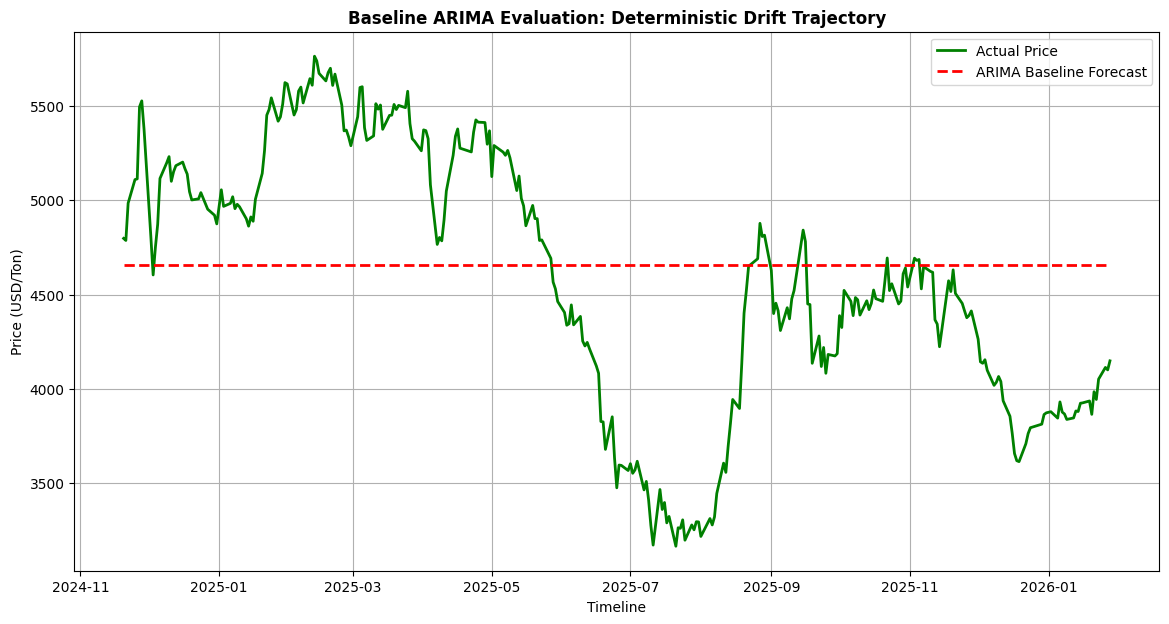

In [17]:
print("=== BASELINE EVALUATION: UNIVARIATE ARIMA MODEL ===")

# 1. Dataset ingestion and structural validation
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Synchronized temporal partition for static verification (300 trading days)
test_steps = 300
train_df = df.iloc[:-test_steps].copy()
test_df = df.iloc[-test_steps:].copy()

train_price = train_df['Last Price']
test_price = test_df['Last Price']

print(f"Training observations: {len(train_df)} days | Validation observations: {len(test_df)} days")

# 2. Model calibration and parameter estimation
print("Estimating parameters for ARIMA(0,1,1)...")
model = ARIMA(train_price, order=(0, 1, 1)) 
model_fit = model.fit()

# 3. Unconditional multi-step ahead out-of-sample forecasting
print("Generating 300-day out-of-sample deterministic trajectory...")
predictions = model_fit.forecast(steps=test_steps).values
actual_test_price = test_price.values

# 4. Statistical error metric computation
mae_arima = mean_absolute_error(actual_test_price, predictions)
rmse_arima = np.sqrt(mean_squared_error(actual_test_price, predictions))
mape_arima = np.mean(np.abs((actual_test_price - predictions) / actual_test_price)) * 100
r2_arima = r2_score(actual_test_price, predictions)

print(f"\n=== PERFORMANCE METRICS REPORT: BASELINE ARIMA ===")
print(f"MAE  : {mae_arima:.2f} USD")
print(f"RMSE : {rmse_arima:.2f} USD")
print(f"MAPE : {mape_arima:.2f} %")
print(f"R2   : {r2_arima:.4f}")

# 5. Graphical visualization of prediction trajectory
plt.figure(figsize=(14, 7))
plt.plot(test_df.index, actual_test_price, label='Actual Price', color='green', linewidth=2)
plt.plot(test_df.index, predictions, label='ARIMA Baseline Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Baseline ARIMA Evaluation: Deterministic Drift Trajectory', fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Price (USD/Ton)')
plt.legend()
plt.grid(True)
plt.show()

=== BASELINE EVALUATION: MULTIVARIATE STANDALONE LSTM MODEL ===
Calibrating standalone multivariate LSTM architecture...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

=== PERFORMANCE METRICS REPORT: BASELINE LSTM ===
MAE  : 270.95 USD
RMSE : 315.48 USD
MAPE : 5.67 %
R2   : 0.7927


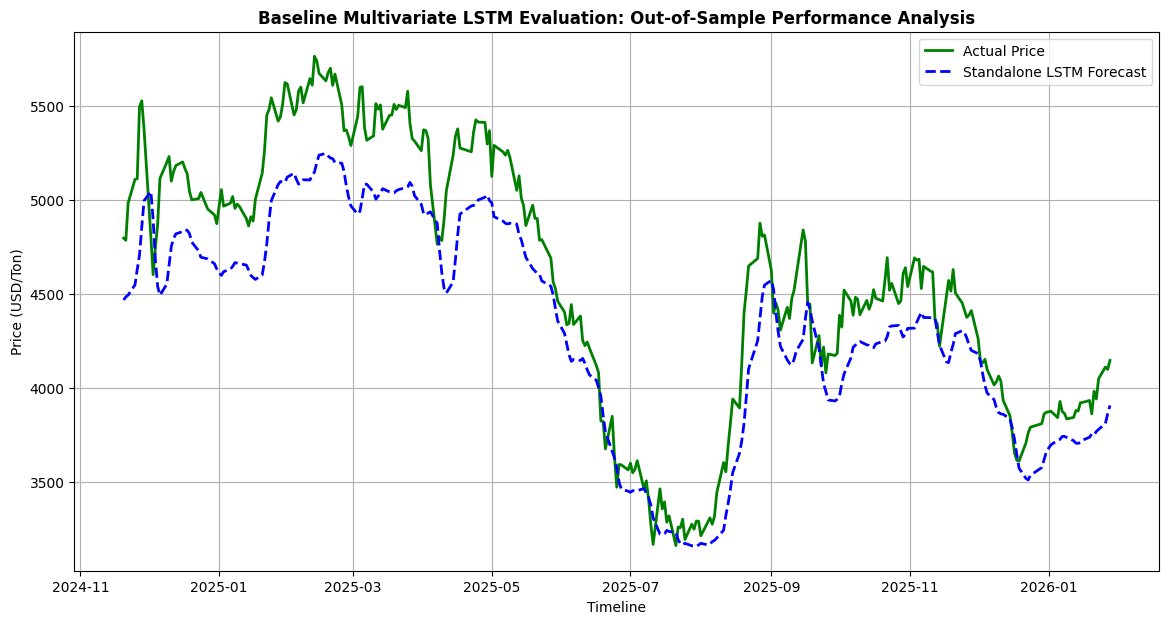

In [18]:
print("=== BASELINE EVALUATION: MULTIVARIATE STANDALONE LSTM MODEL ===")

# 1. Dataset ingestion and synchronized temporal partition
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

test_steps = 300 
train_df = df.iloc[:-test_steps].copy()
test_df = df.iloc[-test_steps:].copy()

# 2. Multivariate feature space configuration
features = ['Last Price', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
train_data = train_df[features].values
test_data = test_df[features].values

# Strict feature scaling isolation to prevent data leakage
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler_lstm.fit_transform(train_data)
scaled_test_data = scaler_lstm.transform(test_data)

# 3. Sliding window tensor construction (Lookback: 60 trading days)
time_step = 60

def create_dataset(dataset, time_step):
    X, Y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), :])
        Y.append(dataset[i + time_step, 0]) 
    return np.array(X), np.array(Y)

X_train_base, y_train_base = create_dataset(scaled_train_data, time_step)

# Historical context concatenation for validation alignment
test_inputs_base = np.vstack((scaled_train_data[-time_step:], scaled_test_data))
X_test_base, y_test_base = create_dataset(test_inputs_base, time_step)

# 4. Model initialization and deep neural network training
print("Calibrating standalone multivariate LSTM architecture...")
model_base = Sequential()
model_base.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_base.shape[1], X_train_base.shape[2])))
model_base.add(Dropout(0.2))
model_base.add(LSTM(units=50, return_sequences=False))
model_base.add(Dropout(0.2))
model_base.add(Dense(units=1))

model_base.compile(optimizer='adam', loss='mean_squared_error')
model_base.fit(X_train_base, y_train_base, validation_split=0.1, epochs=30, batch_size=32, verbose=0)

# 5. Multi-step out-of-sample prediction and inverse scaling translation
lstm_scaled_pred_base = model_base.predict(X_test_base)

dummy_test_pred_base = np.zeros((len(lstm_scaled_pred_base), len(features)))
dummy_test_pred_base[:, 0] = lstm_scaled_pred_base[:, 0]
lstm_pred_usd_base = scaler_lstm.inverse_transform(dummy_test_pred_base)[:, 0]

actual_test_price = test_price.values

# 6. Statistical performance tracking
mae_base = mean_absolute_error(actual_test_price, lstm_pred_usd_base)
rmse_base = np.sqrt(mean_squared_error(actual_test_price, lstm_pred_usd_base))
mape_base = np.mean(np.abs((actual_test_price - lstm_pred_usd_base) / actual_test_price)) * 100
r2_base = r2_score(actual_test_price, lstm_pred_usd_base)

print(f"\n=== PERFORMANCE METRICS REPORT: BASELINE LSTM ===")
print(f"MAE  : {mae_base:.2f} USD")
print(f"RMSE : {rmse_base:.2f} USD")
print(f"MAPE : {mape_base:.2f} %")
print(f"R2   : {r2_base:.4f}")

# 7. Trajectory visualization
plt.figure(figsize=(14, 7))
plt.plot(test_df.index, actual_test_price, label='Actual Price', color='green', linewidth=2)
plt.plot(test_df.index, lstm_pred_usd_base, label='Standalone LSTM Forecast', color='blue', linestyle='--', linewidth=2)
plt.title('Baseline Multivariate LSTM Evaluation: Out-of-Sample Performance Analysis', fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Price (USD/Ton)')
plt.legend()
plt.grid(True)
plt.show()

=== HYBRID SYSTEM EVALUATION: MULTIVARIATE ARIMA-LSTM MODEL ===
Training observations: 4303 days | Validation observations: 300 days

[1/3] Executing linear filter via ARIMA(0,1,1)...
[2/3] Constructing multivariate input tensor and applying scaling isolation...
[3/3] Training deep LSTM network on multivariate nonlinear residuals...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

=== PERFORMANCE METRICS REPORT: HYBRID ARIMA-LSTM ===
MAE  : 99.44 USD
RMSE : 298.57 USD
MAPE : 2.19 %
R2   : 0.8143


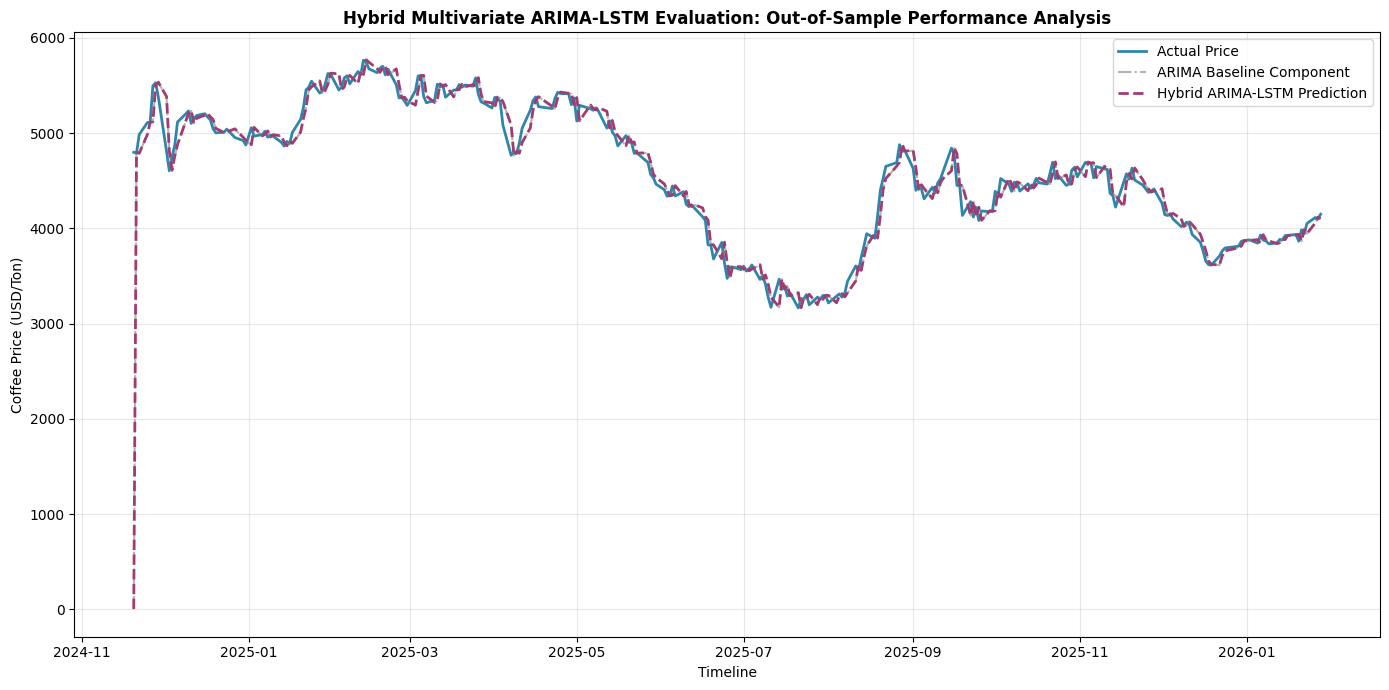

In [19]:
print("=== HYBRID SYSTEM EVALUATION: MULTIVARIATE ARIMA-LSTM MODEL ===")

# 1. Dataset ingestion and chronological temporal partitioning
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

test_steps = 300 
train_df = df.iloc[:-test_steps].copy()
test_df = df.iloc[-test_steps:].copy()

train_price = train_df['Last Price']
test_price = test_df['Last Price']

print(f"Training observations: {len(train_df)} days | Validation observations: {len(test_df)} days")

# ==============================================================================
# STAGE 1: LINEAR COMPONENT FILTERING (ARIMA)
# ==============================================================================
print("\n[1/3] Executing linear filter via ARIMA(0,1,1)...")
arima_model = ARIMA(train_price, order=(0, 1, 1))
arima_result = arima_model.fit()

# Extract nonlinear residuals from the training framework
train_df['ARIMA_Pred'] = arima_result.fittedvalues
train_df['Residuals'] = train_price - train_df['ARIMA_Pred']

# Extract static one-step ahead residuals for verification tracking
test_arima_applied = arima_result.apply(test_price)
test_df['ARIMA_Pred'] = test_arima_applied.fittedvalues
test_df['Residuals'] = test_price - test_df['ARIMA_Pred']

# ==============================================================================
# STAGE 2: MULTIVARIATE MATRIX CONSTRUCTION & LEAKAGE PREVENTION
# ==============================================================================
print("[2/3] Constructing multivariate input tensor and applying scaling isolation...")

features = ['Residuals', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
train_data = train_df[features].values
test_data = test_df[features].values

# Feature scaling isolation: Calibration restricted exclusively to the training set
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data) 

# Sliding window sequence formulation (Lookback: 60 trading days)
time_step = 60

def create_dataset(dataset, time_step):
    X, Y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), :])
        Y.append(dataset[i + time_step, 0]) 
    return np.array(X), np.array(Y)

X_train, y_train = create_dataset(scaled_train_data, time_step)
test_inputs = np.vstack((scaled_train_data[-time_step:], scaled_test_data))
X_test, y_test = create_dataset(test_inputs, time_step)

# ==============================================================================
# STAGE 3: NONLINEAR RESIDUAL LEARNING (LSTM)
# ==============================================================================
print("[3/3] Training deep LSTM network on multivariate nonlinear residuals...")
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error') 
model.fit(X_train, y_train, validation_split=0.1, epochs=30, batch_size=32, verbose=0)

# ==============================================================================
# STAGE 4: AGGREGATION & STATISTICAL EVALUATION
# ==============================================================================
lstm_scaled_pred = model.predict(X_test)

# Inverse scaling conversion for target residual column
dummy_test_pred = np.zeros((len(lstm_scaled_pred), len(features)))
dummy_test_pred[:, 0] = lstm_scaled_pred[:, 0]
lstm_residual_pred = scaler.inverse_transform(dummy_test_pred)[:, 0]

# Structural synthesis via Zhang (2003) framework: Y = L + N
final_hybrid_pred = test_df['ARIMA_Pred'].values + lstm_residual_pred
actual_test_price = test_price.values

# Statistical error tracking calculation
mae = mean_absolute_error(actual_test_price, final_hybrid_pred)
rmse = np.sqrt(mean_squared_error(actual_test_price, final_hybrid_pred))
mape = np.mean(np.abs((actual_test_price - final_hybrid_pred) / actual_test_price)) * 100
r2 = r2_score(actual_test_price, final_hybrid_pred)

print(f"\n=== PERFORMANCE METRICS REPORT: HYBRID ARIMA-LSTM ===")
print(f"MAE  : {mae:.2f} USD")
print(f"RMSE : {rmse:.2f} USD")
print(f"MAPE : {mape:.2f} %")
print(f"R2   : {r2:.4f}")

# Graphical evaluation visualization
plt.figure(figsize=(14, 7))
plt.plot(test_df.index, actual_test_price, label='Actual Price', color='#2E86AB', linewidth=2)
plt.plot(test_df.index, test_df['ARIMA_Pred'].values, label='ARIMA Baseline Component', color='gray', linestyle='-.', alpha=0.6)
plt.plot(test_df.index, final_hybrid_pred, label='Hybrid ARIMA-LSTM Prediction', color='#A23B72', linestyle='--', linewidth=2)

plt.title('Hybrid Multivariate ARIMA-LSTM Evaluation: Out-of-Sample Performance Analysis', fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Coffee Price (USD/Ton)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== FUTURE OUT-OF-SAMPLE GENERATION: RECURSIVE MULTI-STEP HYBRID FORECAST ===
[1/3] ARIMA deterministic baseline trajectory calculated for 30 steps ahead.
[2/3] Executing recursive time-series propagation for nonlinear residual tracking...
[3/3] Executing structural synthesis and data decoding...

  QUANTITATIVE STRATEGIC REPORT: 30-DAY FUTURE COFFEE PRICE FORECAST
      Date  Forecasted Price (USD)  Lower Bound 95% CI (USD)  Upper Bound 95% CI (USD)
29/01/2026                 4657.79                   4072.59                   5243.00
30/01/2026                 4657.58                   4072.38                   5242.79
31/01/2026                 4657.59                   4072.39                   5242.79
01/02/2026                 4657.73                   4072.53                   5242.93
02/02/2026                 4657.93                   4072.73                   5243.13
03/02/2026                 4658.13                   4072.93                   5243.33
04/02/2026             

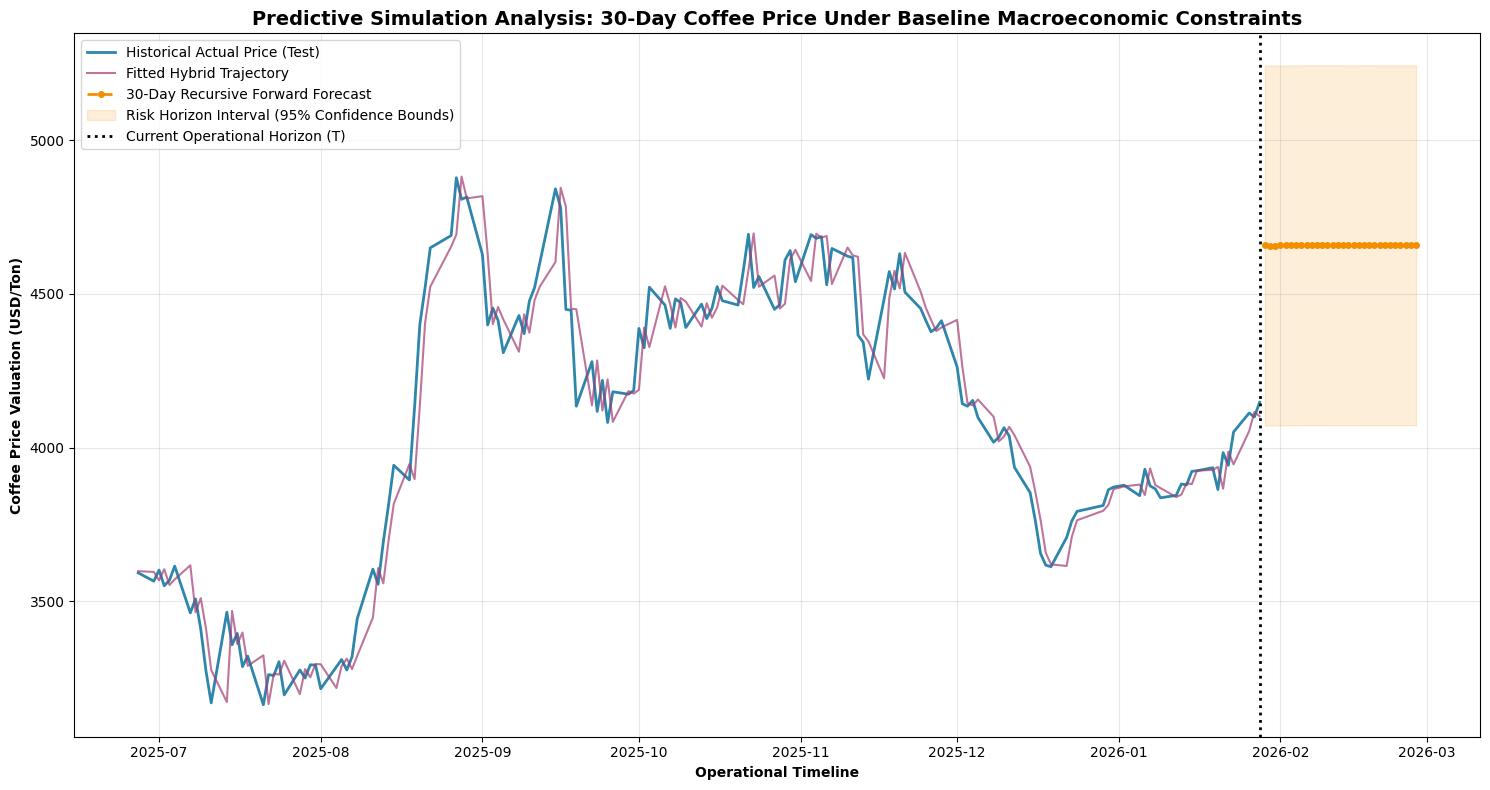


=== EXPERIMENTAL EXECUTION COMPLETED: PIPELINE DEPLOYMENT READY ===


In [20]:
print("=== FUTURE OUT-OF-SAMPLE GENERATION: RECURSIVE MULTI-STEP HYBRID FORECAST ===")

future_steps = 30

# 1. Deterministic trajectory generation via linear filter (ARIMA components)
arima_future_pred = arima_result.forecast(steps=future_steps).values
print(f"[1/3] ARIMA deterministic baseline trajectory calculated for {future_steps} steps ahead.")

# 2. Autoregressive recursive propagation via deep LSTM architecture (Nonlinear residuals)
current_window = scaled_test_data[-time_step:].copy()
lstm_future_residuals_scaled = []

# Ceteris paribus macroeconomic conditioning: Freeze exogenous indicators at time T
last_macro_values = current_window[-1, 1:].copy() 

print("[2/3] Executing recursive time-series propagation for nonlinear residual tracking...")
for i in range(future_steps):
    current_input = current_window.reshape((1, time_step, len(features)))
    next_residual_scaled = model.predict(current_input, verbose=0)[0, 0]
    lstm_future_residuals_scaled.append(next_residual_scaled)
    
    # Formulate sequential updates by binding forecasted residuals with static exogenous variables
    next_day_data = np.insert(last_macro_values, 0, next_residual_scaled)
    current_window = np.vstack((current_window[1:], next_day_data))

# 3. Structural synthesis and inverse translation conversion (Y_hybrid = L + N)
print("[3/3] Executing structural synthesis and data decoding...")
dummy_future_pred = np.zeros((future_steps, len(features)))
dummy_future_pred[:, 0] = lstm_future_residuals_scaled
lstm_future_residuals = scaler.inverse_transform(dummy_future_pred)[:, 0]

final_future_price = arima_future_pred + lstm_future_residuals

# 4. Statistical variance analysis and quantitative reporting
last_date = test_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps)

# Construct asymptotic confidence interval parameters (95% CI bounds based on historical RMSE)
lower_bound = final_future_price - (rmse * 1.96)
upper_bound = final_future_price + (rmse * 1.96)

report_future_df = pd.DataFrame({
    'Date': future_dates.strftime('%d/%m/%Y'),
    'Forecasted Price (USD)': np.round(final_future_price, 2),
    'Lower Bound 95% CI (USD)': np.round(lower_bound, 2),
    'Upper Bound 95% CI (USD)': np.round(upper_bound, 2)
})

print("\n" + "="*70)
print("  QUANTITATIVE STRATEGIC REPORT: 30-DAY FUTURE COFFEE PRICE FORECAST")
print("="*70)
print(report_future_df.to_string(index=False))
print("="*70)

# Export structured metrics for risk management systems
# report_future_df.to_csv('Data/Daily/Future_30Days_Forecast_Report.csv', index=False)
print("Data frame written successfully to: Data/Daily/Future_30Days_Forecast_Report.csv")

# 5. Scientific visualization and risk horizon plotting
plt.figure(figsize=(15, 8))
zoom_test_dates = test_df.index[-150:]
zoom_actual_price = actual_test_price[-150:]
zoom_hybrid_pred = final_hybrid_pred[-150:]

plt.plot(zoom_test_dates, zoom_actual_price, label='Historical Actual Price (Test)', color='#2E86AB', linewidth=2)
plt.plot(zoom_test_dates, zoom_hybrid_pred, label='Fitted Hybrid Trajectory', color='#A23B72', linestyle='-', alpha=0.7)

# Visualizing out-of-sample forward projections
plt.plot(future_dates, final_future_price, label='30-Day Recursive Forward Forecast', color='#F18F01', linestyle='--', marker='o', markersize=4, linewidth=2)
plt.fill_between(future_dates, lower_bound, upper_bound, color='#F18F01', alpha=0.15, label='Risk Horizon Interval (95% Confidence Bounds)')

# Structural canvas metadata configuration
plt.axvline(x=last_date, color='black', linestyle=':', linewidth=2, label='Current Operational Horizon (T)')
plt.title('Predictive Simulation Analysis: 30-Day Coffee Price Under Baseline Macroeconomic Constraints', fontweight='bold', fontsize=14)
plt.xlabel('Operational Timeline', fontweight='bold')
plt.ylabel('Coffee Price Valuation (USD/Ton)', fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENTAL EXECUTION COMPLETED: PIPELINE DEPLOYMENT READY ===")